# Вариант 6: контролируемое обучение ResNet50-IBN
Отдельный эксперимент: старые веса и MVP не меняются. **Run All** проверит разбиение, последовательно сравнит LR → pooling → loss и при достаточном inner-результате обучит три финальных seed.

Бюджет — до 4000 обновлений на запуск, а не прежние короткие эпохи. Полный максимум — 4 screening + 3 seed (до 28000 обновлений), поэтому обучение может занять несколько часов. Все результаты сохраняются автоматически. Подробности — в соседнем README.md.

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'training' / 'stage6.py').exists():
    ROOT = ROOT.parent
if not (ROOT / 'training' / 'stage6.py').exists():
    raise RuntimeError('Откройте notebook внутри Car-classification-MSK')
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Repository:', ROOT)

Repository: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK


## 1. Настройки и устройство
Используется MPS на Mac или CUDA. CPU для полного запуска запрещён. Настройки фиксируются в checkpoint: после начала эксперимента не меняйте их в той же папке.

Порог продвижения 0,50 — заранее заданный фильтр расходов по raw inner mAP@10, а не критерий победы над OSNet.

In [2]:
import json
import shutil
import torch
from training.pipeline import ensure_splits, select_device
from training.stage5 import export_stage5_winner
from training.stage6 import (
    StepBudget, prepare_protocol, run_controlled_screening,
    run_controlled_seeds, write_results_markdown,
)

VARIANT_DIR = ROOT / 'ResNet50-IBN' / 'variant_06_controlled_training'
RESULTS_DIR = VARIANT_DIR / 'results'
WEIGHTS_DIR = VARIANT_DIR / 'weights'
BASE_CONFIG = ROOT / 'OSNet-AIN-x1.0' / 'variant_02_hpo_bnneck_supcon' / 'results' / 'selected_config.json'

BUDGET = StepBudget(
    max_steps=4000,
    evaluation_interval=200,
    warmup_steps=400,
    min_steps=2000,
    patience=5,
    promotion_min_map=0.50,
)
BUDGET.validate()
device = select_device()
print('Device:', device)
if device.type == 'cpu':
    raise RuntimeError('MPS/CUDA недоступен: проверьте PyTorch и kernel, полный запуск на CPU остановлен.')
free_gib = shutil.disk_usage(ROOT).free / 1024**3
print(f'Свободное место: {free_gib:.2f} GiB; рекомендуется не менее 8 GiB.')
saved_gib = sum(p.stat().st_size for p in WEIGHTS_DIR.rglob('*.pt')) / 1024**3
required_free_gib = max(1.0, 6.0 - saved_gib)
if free_gib < required_free_gib:
    raise RuntimeError(f'Нужно ещё {required_free_gib:.2f} GiB свободного места. Старые результаты автоматически не удаляются.')
if not BASE_CONFIG.exists():
    raise FileNotFoundError(BASE_CONFIG)
print('Budget:', BUDGET)

Device: mps
Свободное место: 6.66 GiB; рекомендуется не менее 8 GiB.
Budget: StepBudget(max_steps=4000, evaluation_interval=200, warmup_steps=400, min_steps=2000, patience=5, promotion_min_map=0.5)


## 2. Аудит и замороженный протокол
Читается только train.csv. Проверяются реальные SHA-256 кадров и непересечение outer частей. Новый inner split группирует связанные identity/полные кадры. Query/gallery для inner evaluation фиксируются одним seed независимо от seed обучения.

In [3]:
rows, split = ensure_splits()
protocol = prepare_protocol(rows, split, RESULTS_DIR)
for name, identities in protocol['inner'].items():
    identity_set = set(identities)
    count = sum(row['vehicle_id'] in identity_set for row in rows)
    print(f'inner {name}: {len(identities)} identities, {count} изображений')
print('Outer train:', len(split['identities']['train']), 'identities')
print('Fingerprint:', protocol['data_sha256'])
print('Identity/frame audit:', protocol['identity_and_exact_frame_disjoint'])

Audit train frame hashes:   0%|          | 0/9556 [00:00<?, ?it/s]

inner train: 741 identities, 4605 изображений
inner validation: 184 identities, 1112 изображений
Outer train: 925 identities
Fingerprint: e749116a9239e72936e91d1ec4b7f8ff6914964ce0c000e3c1d89a6c899c7581
Identity/frame audit: True


## 3. Последовательные абляции
Четыре запуска с одной ImageNet-инициализацией и одинаковым seed:
1. GeM + SupCon, encoder LR 1e-4.
2. То же, LR 3e-4.
3. Лучший LR, меняется только GeM → AvgPool.
4. Лучший LR/pooling, меняется только SupCon → Triplet.

CE, consistency и численный вес metric loss фиксированы. Early stopping разрешён после 2000 шагов, patience 5 проверок. Одна отчётная эпоха — 200 обновлений. Печатаются время эпохи, текущий бюджет, предъявления и ETA. Повторный Run All продолжит с последнего сохранённого блока, готовые модели не переобучаются.

In [4]:
screening = run_controlled_screening(
    rows, protocol, device, BASE_CONFIG, RESULTS_DIR, WEIGHTS_DIR, budget=BUDGET,
)
print(json.dumps({
    'winner': screening['winner']['name'],
    'inner_mAP_at_10': screening['winner']['best_mAP_at_10'],
    'selected_steps': screening['winner']['selected_steps'],
    'promoted': screening['promoted'],
}, ensure_ascii=False, indent=2))


Запуск: screening/lr_1e-04_gem_supcon | LR=0.0001 | gem/supcon | seed=20260915


steps 1–200:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 1/20 | осталось эпох: 19 | шаги 200/4000, осталось 3800 | эпоха: 00:03:14 | прошло: 00:03:14 | ETA ≤ 01:01:32 | предъявлений: 6400, условных проходов: 1.39 | inner mAP@10: 0.2003


steps 201–400:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 2/20 | осталось эпох: 18 | шаги 400/4000, осталось 3600 | эпоха: 00:03:23 | прошло: 00:06:37 | ETA ≤ 00:59:37 | предъявлений: 12800, условных проходов: 2.78 | inner mAP@10: 0.2631


...

Эпоха 18/20 | осталось эпох: 2 | шаги 3600/4000, осталось 400 | эпоха: 00:03:05 | прошло: 00:55:52 | ETA ≤ 00:06:12 | предъявлений: 115200, условных проходов: 25.02 | inner mAP@10: 0.4753


steps 3601–3800:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 19/20 | осталось эпох: 1 | шаги 3800/4000, осталось 200 | эпоха: 00:03:05 | прошло: 00:58:57 | ETA ≤ 00:03:06 | предъявлений: 121600, условных проходов: 26.41 | inner mAP@10: 0.4769


steps 3801–4000:   0%|          | 0/200 [00:00<?, ?it/s]

Эпоха 20/20 | осталось эпох: 0 | шаги 4000/4000, осталось 0 | эпоха: 00:03:05 | прошло: 01:02:02 | ETA ≤ 00:00:00 | предъявлений: 128000, условных проходов: 27.80 | inner mAP@10: 0.4787
{
  "winner": "screening/triplet",
  "inner_mAP_at_10": 0.48134209768563513,
  "selected_steps": 3200,
  "promoted": false
}


## 4. Кривые обучения
Все кривые ниже относятся только к inner split. Внешняя validation пока не используется.

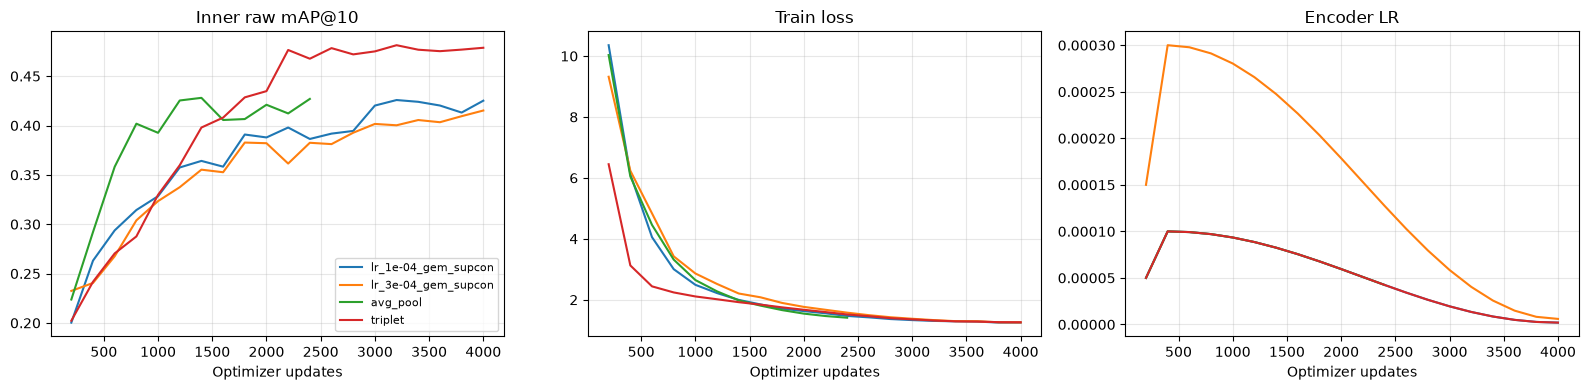

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for run in screening['runs']:
    history = json.loads((RESULTS_DIR / run['name'] / 'history.json').read_text())
    steps = [item['step'] for item in history]
    label = run['name'].split('/')[-1]
    axes[0].plot(steps, [item['validation']['mAP_at_10'] for item in history], label=label)
    axes[1].plot(steps, [item['train']['loss'] for item in history], label=label)
    axes[2].plot(steps, [item['lr']['last']['encoder'] for item in history], label=label)
for axis, title in zip(axes, ('Inner raw mAP@10', 'Train loss', 'Encoder LR')):
    axis.set(xlabel='Optimizer updates', title=title)
    axis.grid(alpha=.3)
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5. Три seed и итоговая оценка
Если inner mAP@10 < 0,50, этот этап корректно пропускается. Иначе выбранная конфигурация стартует заново на всех outer-train identity и останавливается на выбранном inner шаге. Горизонт LR остаётся 4000.

Только после обучения: подбор reranking/отказа на calibration, затем один outer validation отчёт для каждого seed. Seed для экспорта заранее фиксирован первым; по validation он не выбирается. Это development-эксперимент, не обучение финальной модели на всех доступных размеченных данных.

In [6]:
comparison = run_controlled_seeds(
    rows, split, protocol, screening, device, RESULTS_DIR, WEIGHTS_DIR,
)
report_path = write_results_markdown(screening, comparison, RESULTS_DIR)
print(json.dumps({key: value for key, value in comparison.items() if key != 'runs'},
                 ensure_ascii=False, indent=2))
print('Markdown report:', report_path)

{
  "status": "not_promoted",
  "inner_mAP_at_10": 0.48134209768563513,
  "promotion_min_map": 0.5,
  "reason": "Inner-only budget gate; no outer evaluation or final training",
  "beats_active_reference": false
}
Markdown report: /Users/elvsevolod/Desktop/учеба/Учёба 4 курс/Хакатон мск сентябрь/Car-classification-MSK/ResNet50-IBN/variant_06_controlled_training/results/RESULTS.md


## 6. Отдельный ONNX и parity
Если финальные seed выполнены, экспортируется первый заранее заданный seed. Проверяются PyTorch/ONNX parity, размер, forward-only latency. Это не полный официальный benchmark с чтением/декодированием/кропом. Веса остаются в каталоге эксперимента, MVP не меняется.

In [7]:
if comparison['status'] == 'completed':
    export = export_stage5_winner(
        comparison, split, rows, WEIGHTS_DIR,
        WEIGHTS_DIR / 'resnet50_ibn_stage6.onnx',
        RESULTS_DIR / 'export_summary.json',
        benchmark_device=device,
    )
    print(json.dumps({
        'onnx': export['onnx'],
        'onnx_size_mb': export['onnx_size_mb'],
        'parity': export['parity'],
        'benchmark': export['benchmark'],
    }, ensure_ascii=False, indent=2))
else:
    print('Кандидат не прошёл inner-порог: финальное обучение, outer evaluation и экспорт пропущены.')
print('Готово. Активная OSNet и MVP не изменены.')

Кандидат не прошёл inner-порог: финальное обучение, outer evaluation и экспорт пропущены.
Готово. Активная OSNet и MVP не изменены.
